In [1]:
import os
import csv
import pandas as pd
import numpy as np
import scanpy as sc
from tqdm import tqdm
import matplotlib.pyplot as plt
from Helper.Load_Anndata import read_and_filter_h5ad
from Helper.Process_Anndata import AnnObject
import Helper.train_and_plot as tp
import Helper.utils as hutil
import math
from collections import Counter
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
## cell type annotation obtained from the original paper
raw_adata = read_and_filter_h5ad("../Mouse_Tabula_Muris/Marrow_droplet.h5ad", "cell_ontology_class", "age")

Checking low count cell types...
promonocyte + macropage  has too low counts
CD4+ positive macrophage  has too low counts
basophil  has too low counts
erythroid progenitor cell  has too low counts
plasma cell  has too low counts
immature B cell  has too low counts
unknown cell-1  has too low counts
late pro B cell  has too low counts
pre B cell  has too low counts
NK cell  has too low counts
unknown cell-2  has too low counts
erythrocyte  has too low counts
naïve B cell  has too low counts
Checking skewed count cell types...
proerythroblast + erythroblast  has skewed cell counts


In [4]:
organ = "Bone-Marrow"
processed_folder = "../2024_Nov/Processed_data/"

In [5]:
font_size_config = {
    'axes.titlesize': 16,  # Title font size
    'axes.labelsize': 14,  # Axes labels (x and y) font size
    'xtick.labelsize': 12,  # X-axis tick label font size
    'ytick.labelsize': 12,  # Y-axis tick label font size
}

## Preprocess Anndata

In [6]:
adataObject = AnnObject(raw_adata, "cell_ontology_class", "age", "m")

logarithmizing the adata into processed_object


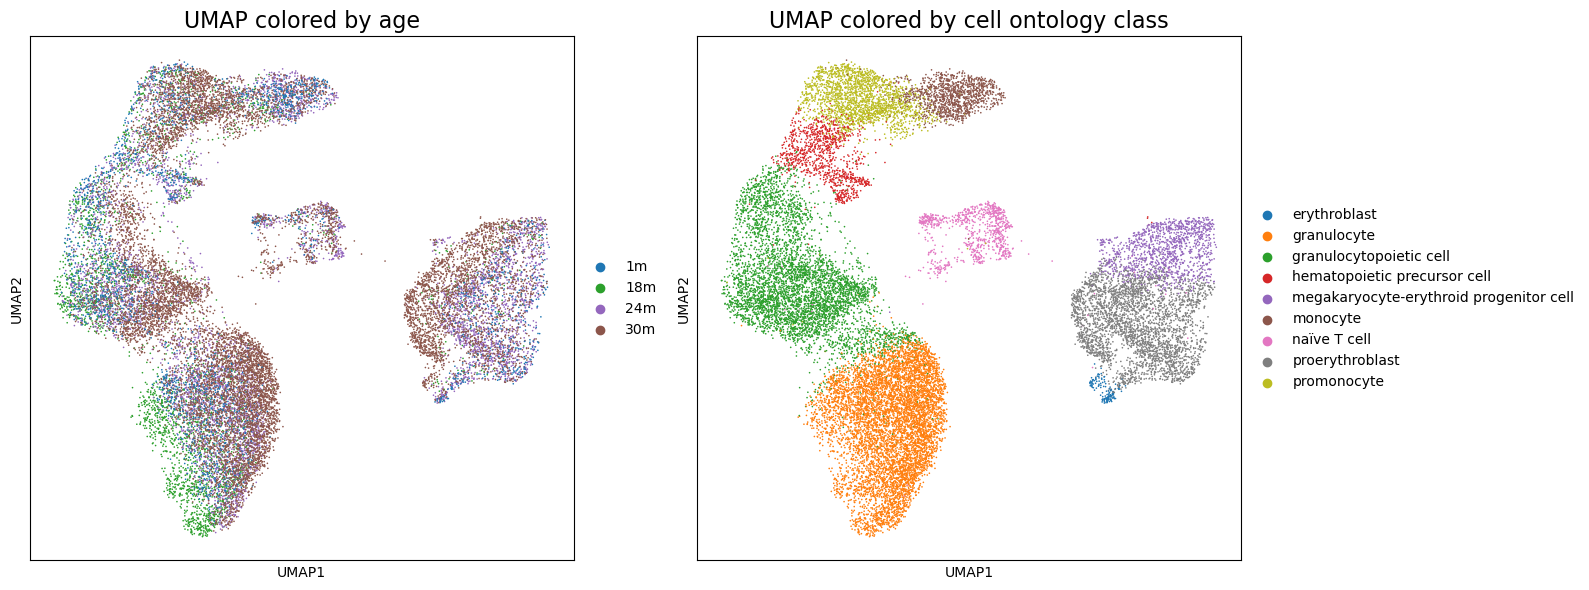

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

with plt.rc_context(font_size_config):
    sc.pl.umap(adataObject.processed_adata, color="age", ax=axs[0], show=False, title='UMAP colored by age')

    sc.pl.umap(adataObject.processed_adata, color="cell_ontology_class", ax=axs[1], show=False, title='UMAP colored by cell ontology class')

plt.tight_layout()
plt.show()

In [8]:
selected_gene_by_frac = hutil.filter_low_genes(adataObject.raw_counts, adataObject.celltype_dict)

100%|███████████████████████████████████████████████| 9/9 [00:02<00:00,  3.94it/s]


In [9]:
correlated_index = hutil.get_correlated_genes(adataObject, organ, selected_gene_by_frac)

Correlation output directory already exists.
Deleting previous correlated_info files...
Processing cell type granulocytopoietic cell...
Processing cell type hematopoietic precursor cell...
Processing cell type granulocyte...
Processing cell type promonocyte...
Processing cell type monocyte...
Processing cell type naïve T cell...
Processing cell type megakaryocyte-erythroid progenitor cell...
Processing cell type proerythroblast...
Processing cell type erythroblast...


## Compute the frequencies

In [10]:
metaCells, metaAges = hutil.get_metaCells(adataObject.celltype_dict, adataObject.raw_counts, adataObject.age_dict)

In [11]:
pred_freq_matrices, freq_age_group = hutil.get_gene_frequencies(metaCells, metaAges, adataObject.raw_counts.index, 
                                                                selected_gene_by_frac)

processing celltype:  granulocytopoietic cell
processing celltype:  hematopoietic precursor cell
processing celltype:  granulocyte
processing celltype:  promonocyte
processing celltype:  monocyte
processing celltype:  naïve T cell
processing celltype:  megakaryocyte-erythroid progenitor cell
processing celltype:  proerythroblast
processing celltype:  erythroblast


## Run model and generate results
r: Expected frequency from the linear model
k: counts of this specific gene
t: sum of the counts across all genes for that cell

In [12]:
def initialize_output_file(organ, r_squareds_dir="./r_squareds"):
    os.makedirs(r_squareds_dir, exist_ok=True)
    file_path = os.path.join(r_squareds_dir, f"{organ}_r_squared_summary.csv")
    print(file_path)
    if os.path.isfile(file_path):
        print("Deleting previous r_squared file")
        os.remove(file_path)
    return file_path

In [13]:
num_features = []
pred_age_plot = {}
file_path = f"./R_Squareds/{organ}_r_squared_summary.csv"
initialize_output_file(organ)

# Dictionary to store r_squared values for each cell type and gene count
r_squared_results = {}

./r_squareds/Bone-Marrow_r_squared_summary.csv
Deleting previous r_squared file


Processing cell type: granulocytopoietic cell


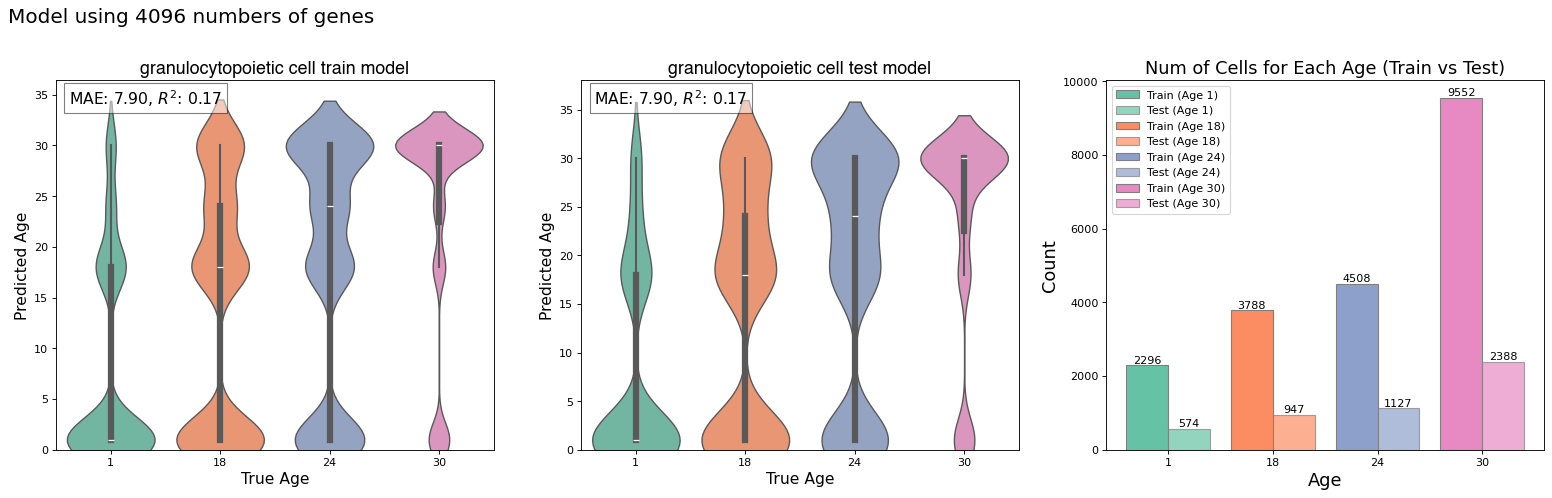

Processing cell type: hematopoietic precursor cell


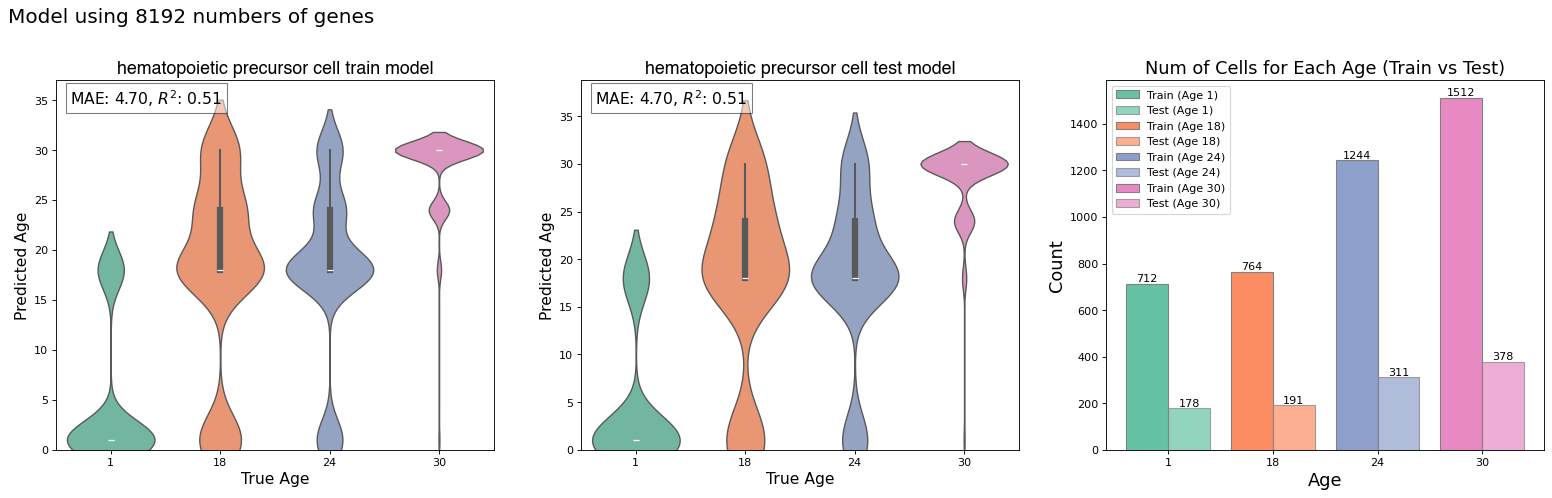

Processing cell type: granulocyte


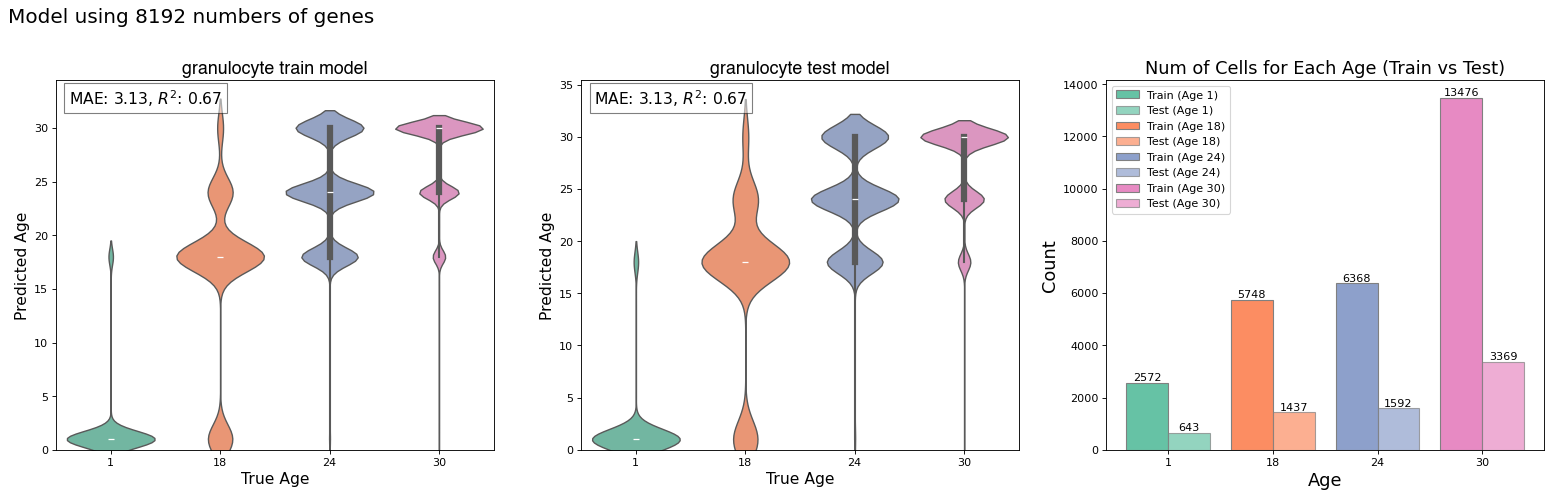

Processing cell type: promonocyte


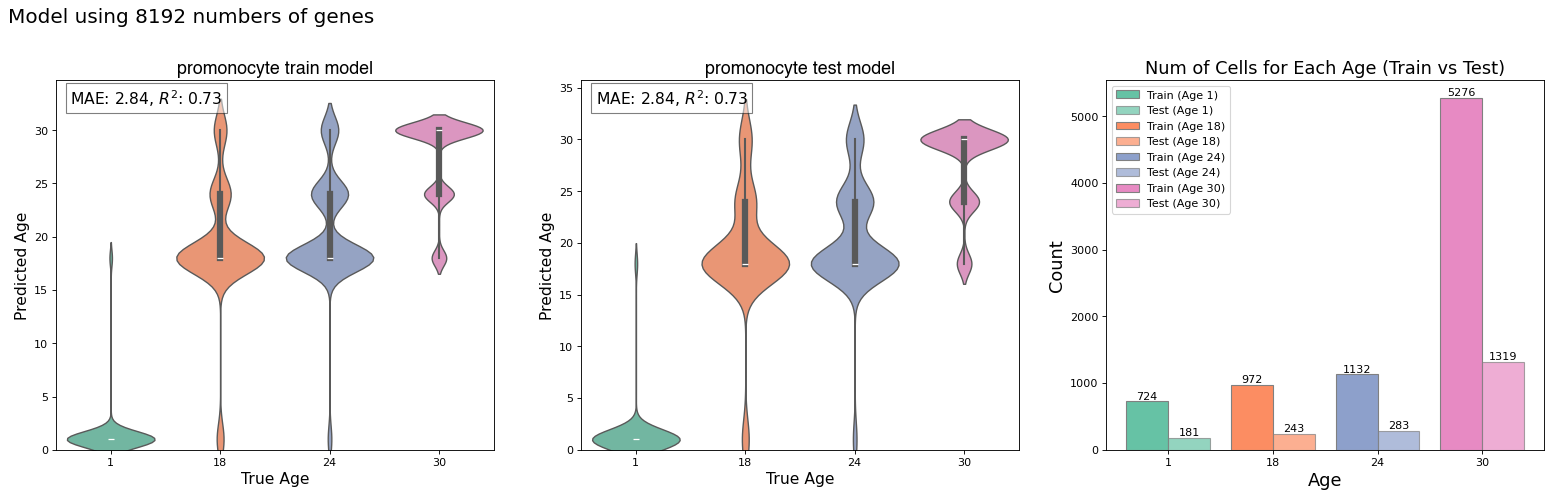

Processing cell type: monocyte


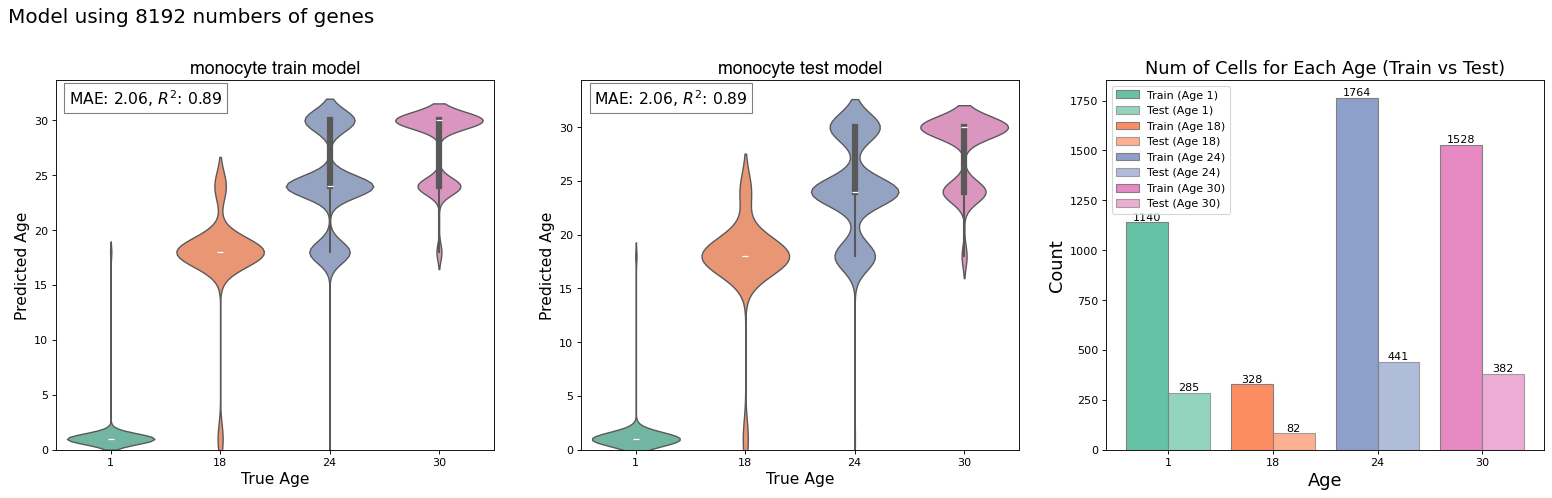

Processing cell type: naïve T cell


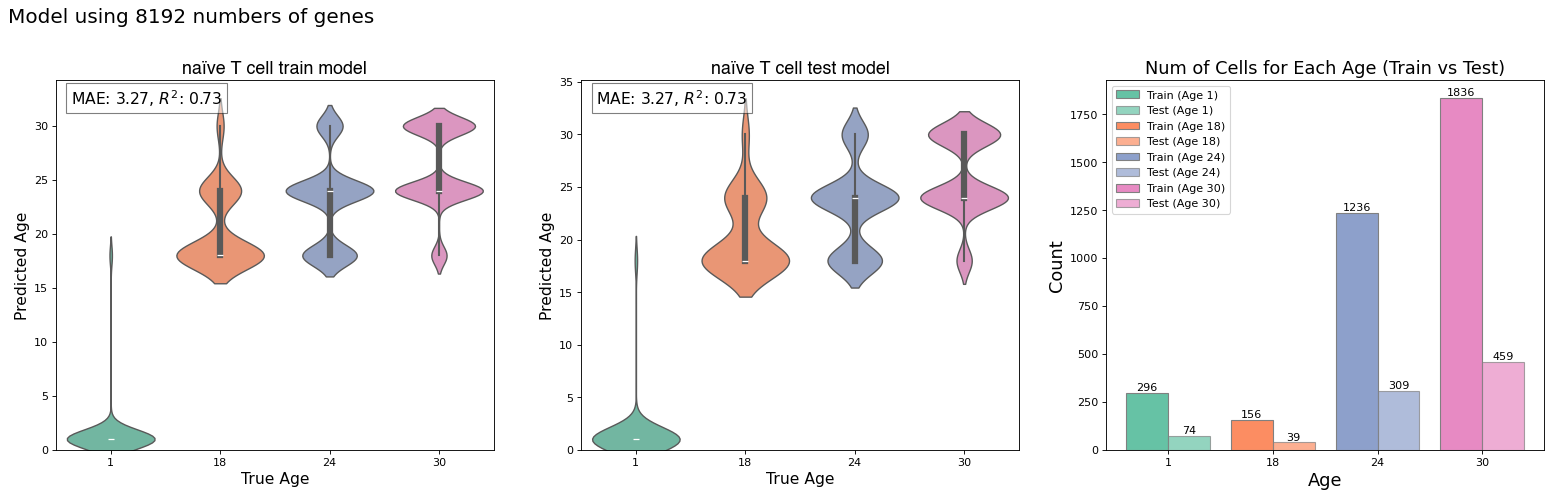

Processing cell type: megakaryocyte-erythroid progenitor cell


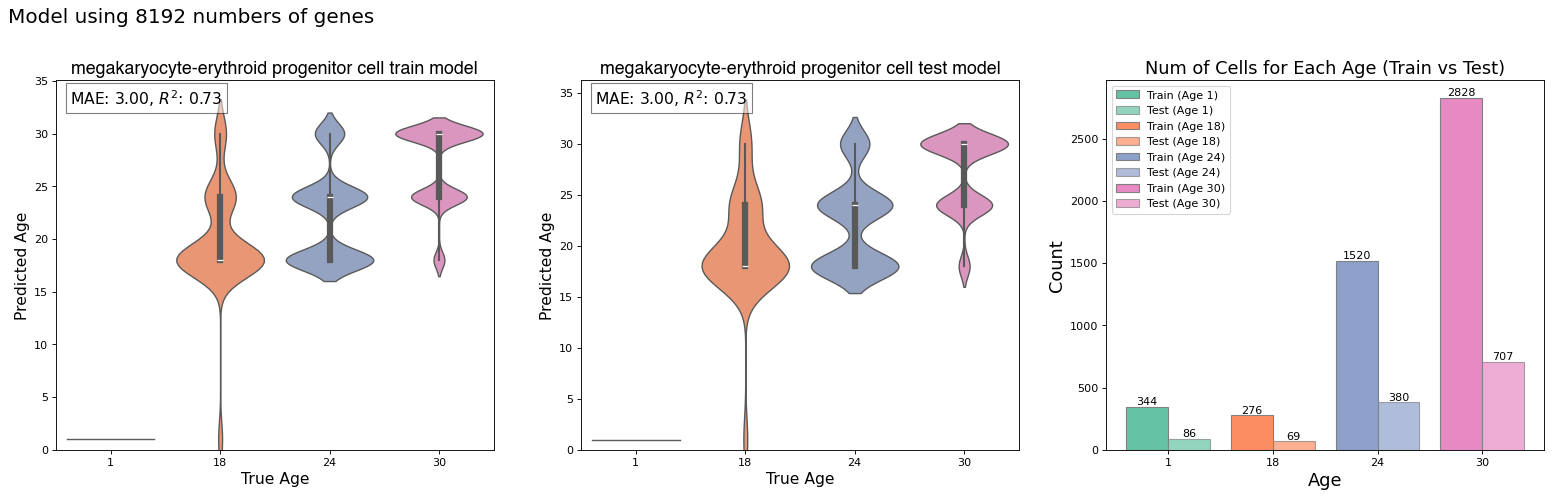

Processing cell type: proerythroblast


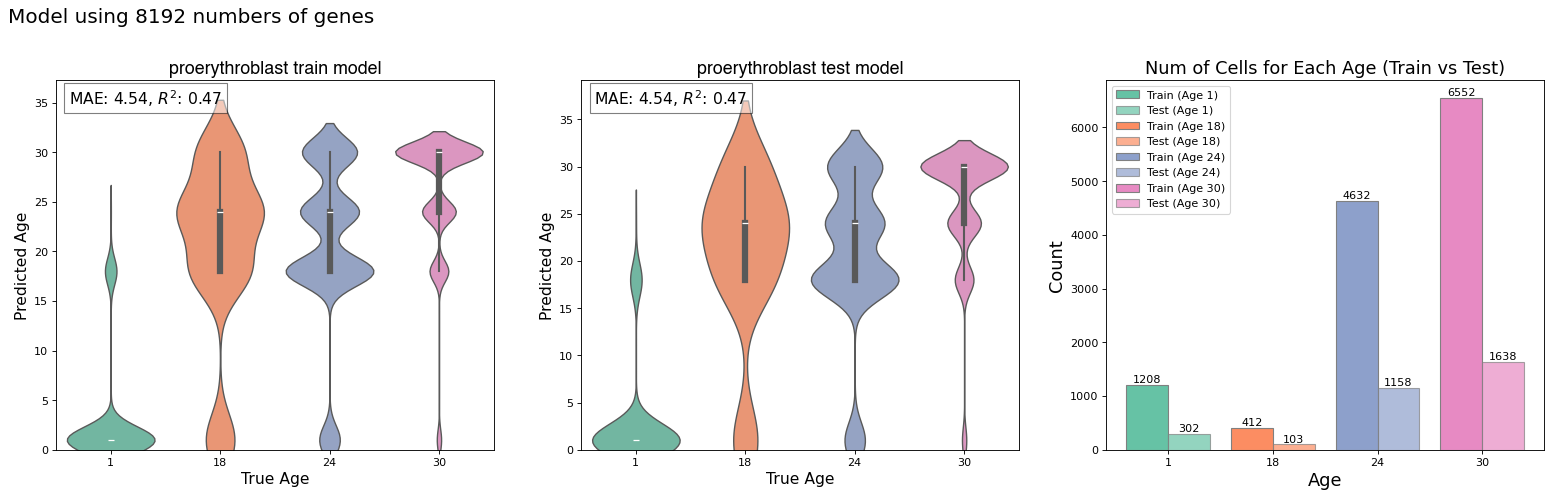

Processing cell type: erythroblast


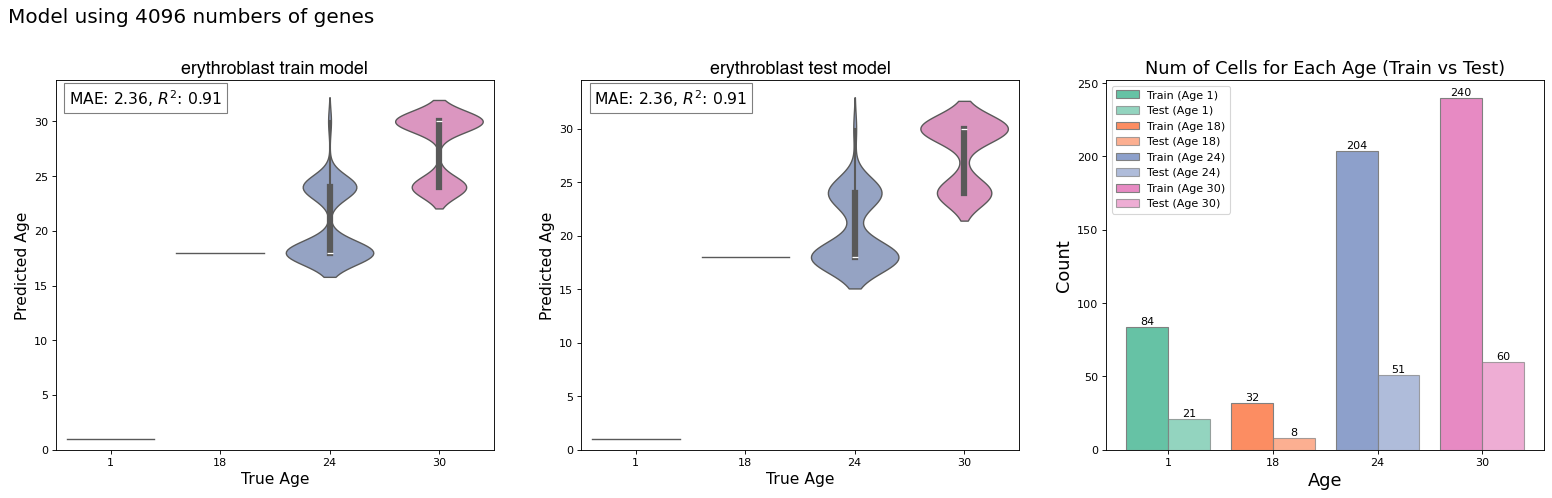

In [14]:
# Iterate over each cell type in the predicted frequency matrices
for celltype in adataObject.celltype_dict:
    print(f"Processing cell type: {celltype}")
    
    cell_group = adataObject.celltype_dict[celltype]
    raw_cells = np.array(adataObject.raw_counts[cell_group])
    
    ages = np.array([adataObject.age_dict[cell] for cell in cell_group])
    donor_ids = np.array([adataObject.processed_adata.obs.loc[cell, "mouse.id"] for cell in cell_group])
    unique_donors = np.unique(donor_ids)
    donor_kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Select the correlated genes for the current cell type
    correlated_index_list = correlated_index[celltype]

    # Store cross-entropy results for different gene counts
    celltype_r_squared = {}
    
    def try_model_across_fold():
        train_r2s = []
        for fold_idx, (train_idx, _) in enumerate(donor_kf.split(unique_donors)):
            train_donors = unique_donors[train_idx]
            # Masks for cell-level selection
            train_mask = np.isin(donor_ids, train_donors)
            # Get raw counts and ages per fold
            X_train = raw_cells[:, train_mask].T[:, selected_index]
            y_train = ages[train_mask]

            # Run the poisson function
            train_predicted_ages = tp._run_poisson(
                pred_freqs, X_train, y_train, freq_age_group[celltype]
            )
            r2 = (pearsonr(y_train, train_predicted_ages)[0]) ** 2
            train_r2s.append(r2)
        return train_r2s
    
    i = 0
    while (2**i) <= len(correlated_index_list):
#         print(2**i)
        gene_count = 2**i
        i += 1
        selected_index = correlated_index_list[:gene_count]
        # Retrieve the predicted frequency matrix for the current cell type
        pred_freqs = pred_freq_matrices[celltype][selected_index, :]
        train_r2s = try_model_across_fold()
        r2 = sum(train_r2s) / 5
        celltype_r_squared[gene_count] = r2
    
    r_squared_results[celltype] = {num_genes: (r_squareds if not np.isnan(r_squareds).any() else 0) for num_genes, r_squareds in celltype_r_squared.items()}
    optimal_gene_counts = max(r_squared_results[celltype], key=r_squared_results[celltype].get)
    num_features.append({"celltype": celltype, "num_features": optimal_gene_counts})
    
    optimal_index = correlated_index_list[:optimal_gene_counts]
    optimal_pred_freqs = pred_freq_matrices[celltype][optimal_index, :]
    
    train_ages, store_train_predict, test_ages, store_test_predict, full_predicted_ages = tp.test_model_across_fold(donor_kf, donor_ids, unique_donors, raw_cells, ages, optimal_index, optimal_pred_freqs, freq_age_group[celltype])
    
    # save the predicted ages to anndata for plotting later
    adataObject.processed_adata.obs.loc[cell_group, "pred_age"] = full_predicted_ages

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6), dpi=80)
    tp._plot_violin(file_path = file_path, ax = ax1, x = train_ages, y = store_train_predict, name = celltype, record = False)
    tp._plot_violin(file_path = file_path, ax = ax2, x = test_ages, y = store_test_predict, name = celltype)
    tp._plot_cell_count(ax3, dict(sorted(Counter(train_ages).items())), dict(sorted(Counter(test_ages).items())))
    fig.text(0.1, 1, f"Model using {optimal_gene_counts} numbers of genes", fontsize = 18)
    fig.savefig(f"./Model_Figures/{organ}_{celltype}_model.png", bbox_inches='tight', dpi = 300)
    plt.show()
tp.write_feature_summary(organ, num_features)

## Save predicted age

In [15]:
adataObject.processed_adata.obs["pred_age"] = [str(int(x)) + "m" for x in adataObject.processed_adata.obs["pred_age"]]

## Save processed adata

In [16]:
adataObject.processed_adata.write_h5ad(filename = f"{processed_folder}{organ}_Processed_Data.h5ad", compression='gzip')